# Phase 2 TFIM-QRC v1.5 Readout Robustness Probe

The best v1.5 reservoir improved all test metrics but remains far from the classical ESN baseline. This notebook does not run new reservoir architectures. It reuses the best v1.5 configuration and tests whether the readout is being hurt by noisy/shifted reservoir features.

Tested readout controls:

- train-only feature winsorization at 1/99 percentiles;
- train-only top-k feature selection by absolute feature-target correlation;
- ridge alpha sweep.

This is cheap compared with new QRC simulations and should be interpreted as readout robustness, not a new QRC architecture.

In [1]:
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from qpitome_qrc.data.features import FEATURE_COLUMNS
from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.pca import fit_transform_pca_splits_train_only
from qpitome_qrc.data.splits import chronological_tabular_split
from qpitome_qrc.evaluation.metrics import evaluate_volatility_forecast
from qpitome_qrc.qrc.tfim_reservoir import (
    TFIMQRCConfig,
    _safe_feature_target_correlations,
    diagnose_reservoir_feature_splits,
    fit_tfim_qrc_regressor,
    make_qrc_sequence_splits,
    summarize_qrc_result,
)

## 1. Data and best v1.5 reservoir run

This recomputes the best v1.5 run once so the notebook is self-contained.

In [2]:
target = "future_rv_20d"

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)

pca6 = fit_transform_pca_splits_train_only(
    splits,
    feature_columns=FEATURE_COLUMNS,
    target_columns=[target],
    n_components=6,
    prefix="pca6",
)

sequence_splits_6 = make_qrc_sequence_splits(
    pca6.splits,
    feature_columns=pca6.feature_columns,
    target_column=target,
    lookback_days=40,
)

best_config = TFIMQRCConfig(
    qubits=6,
    pca_components=6,
    lookback_days=40,
    anchor_count=6,
    anchor_policy="even",
    observable_mode="zxzz",
    collect_anchor_features=True,
    topology="full",
    trotter_steps_per_anchor=3,
    virtual_nodes_per_anchor=3,
    coupling_scale=0.7,
    transverse_field=0.5,
    evolution_time=0.5,
    angle_max=np.pi / 2,
    ridge_alpha=3000.0,
    target_transform="log",
    seed=42,
    use_disorder=True,
    disorder_strength=0.20,
)

best_result = fit_tfim_qrc_regressor(
    sequence_splits_6,
    config=best_config,
    target=target,
    verbose=True,
)

pd.DataFrame([summarize_qrc_result(best_result)]).T

QRC sample 0/5420
QRC sample 250/5420
QRC sample 500/5420
QRC sample 750/5420
QRC sample 1000/5420
QRC sample 1250/5420
QRC sample 1500/5420
QRC sample 1750/5420
QRC sample 2000/5420
QRC sample 2250/5420
QRC sample 2500/5420
QRC sample 2750/5420
QRC sample 3000/5420
QRC sample 3250/5420
QRC sample 3500/5420
QRC sample 3750/5420
QRC sample 4000/5420
QRC sample 4250/5420
QRC sample 4500/5420
QRC sample 4750/5420
QRC sample 5000/5420
QRC sample 5250/5420
QRC sample 0/1219
QRC sample 250/1219
QRC sample 500/1219
QRC sample 750/1219
QRC sample 1000/1219
QRC sample 0/1019
QRC sample 250/1019
QRC sample 500/1019
QRC sample 750/1019
QRC sample 1000/1019


,0
qubits,6
pca_components,6
lookback_days,40
anchor_count,6
anchor_policy,even
observable_mode,zxzz
trotter_steps_per_anchor,3
virtual_nodes_per_anchor,3
topology,full
coupling_scale,0.7


## 2. Helper functions

In [3]:
def winsorize_train_bounds(H_train, lower_pct=1.0, upper_pct=99.0):
    lower = np.percentile(H_train, lower_pct, axis=0)
    upper = np.percentile(H_train, upper_pct, axis=0)
    return lower, upper


def apply_winsor(H, lower, upper):
    return np.clip(H, lower, upper)


def fit_predict_readout(H_train, y_train, H_val, H_test, *, alpha):
    scaler = StandardScaler()
    H_train_scaled = scaler.fit_transform(H_train)
    H_val_scaled = scaler.transform(H_val)
    H_test_scaled = scaler.transform(H_test)

    y_fit = np.log(np.maximum(y_train, 1e-8))
    model = Ridge(alpha=alpha)
    model.fit(H_train_scaled, y_fit)

    return (
        np.exp(model.predict(H_train_scaled)),
        np.exp(model.predict(H_val_scaled)),
        np.exp(model.predict(H_test_scaled)),
    )


def metrics_row(y_train, y_val, y_test, pred_train, pred_val, pred_test):
    train_m = evaluate_volatility_forecast(y_train, pred_train)
    val_m = evaluate_volatility_forecast(y_val, pred_val)
    test_m = evaluate_volatility_forecast(y_test, pred_test)
    return {
        "train_rmse": train_m.rmse,
        "val_rmse": val_m.rmse,
        "test_rmse": test_m.rmse,
        "train_qlike": train_m.qlike,
        "val_qlike": val_m.qlike,
        "test_qlike": test_m.qlike,
        "train_mz_r2": train_m.mz_r2,
        "val_mz_r2": val_m.mz_r2,
        "test_mz_r2": test_m.mz_r2,
    }

## 3. Readout robustness sweep

All feature selection and clipping is fit on the training split only.

In [4]:
H_train = best_result.train_features
H_val = best_result.val_features
H_test = best_result.test_features

_, y_train, _ = sequence_splits_6["train"]
_, y_val, _ = sequence_splits_6["val"]
_, y_test, _ = sequence_splits_6["test"]

rows = []
diag_rows = []

for winsor in [False, True]:
    if winsor:
        lower, upper = winsorize_train_bounds(H_train, 1.0, 99.0)
        Hw_train = apply_winsor(H_train, lower, upper)
        Hw_val = apply_winsor(H_val, lower, upper)
        Hw_test = apply_winsor(H_test, lower, upper)
    else:
        Hw_train, Hw_val, Hw_test = H_train, H_val, H_test

    corr = _safe_feature_target_correlations(Hw_train, y_train)
    order = np.argsort(np.abs(corr))

    for top_k in [20, 40, 80, 120, H_train.shape[1]]:
        idx = order[-top_k:]
        Hs_train = Hw_train[:, idx]
        Hs_val = Hw_val[:, idx]
        Hs_test = Hw_test[:, idx]

        for alpha in [1000.0, 3000.0, 10000.0, 30000.0]:
            pred_train, pred_val, pred_test = fit_predict_readout(
                Hs_train, y_train, Hs_val, Hs_test, alpha=alpha
            )
            row = metrics_row(y_train, y_val, y_test, pred_train, pred_val, pred_test)
            row.update({
                "winsor": winsor,
                "top_k": top_k,
                "alpha": alpha,
                "n_features": Hs_train.shape[1],
            })
            rows.append(row)

        diag = diagnose_reservoir_feature_splits(
            Hs_train,
            Hs_val,
            Hs_test,
            y_train,
            y_val,
            y_test,
        )
        diag.insert(0, "winsor", winsor)
        diag.insert(1, "top_k", top_k)
        diag_rows.append(diag)

readout_sweep = pd.DataFrame(rows)
readout_diagnostics = pd.concat(diag_rows, ignore_index=True)

readout_sweep.sort_values(["test_rmse", "test_qlike"], ascending=[True, True]).head(20)

,train_rmse,val_rmse,test_rmse,train_qlike,val_qlike,test_qlike,train_mz_r2,val_mz_r2,test_mz_r2,winsor,top_k,alpha,n_features
1,0.086110,0.064751,0.100032,-2.454203,-2.997733,-2.048159,0.287056,0.039681,0.104994,False,20,3000.0,20
21,0.086174,0.064760,0.100035,-2.452895,-2.997590,-2.047098,0.285771,0.039712,0.105035,True,20,3000.0,20
0,0.084923,0.065540,0.100087,-2.473913,-2.988290,-2.049382,0.297387,0.041675,0.104994,False,20,1000.0,20
20,0.085002,0.065545,0.100089,-2.472480,-2.988152,-2.048113,0.295935,0.041668,0.105001,True,20,1000.0,20
25,0.086034,0.064299,0.100113,-2.454621,-3.000640,-2.047380,0.287289,0.043454,0.104066,True,40,3000.0,40
5,0.085970,0.064300,0.100126,-2.455944,-3.000631,-2.047581,0.288620,0.043384,0.103745,False,40,3000.0,40
24,0.084871,0.064856,0.100245,-2.474237,-2.992700,-2.049360,0.297456,0.046925,0.103985,True,40,1000.0,40
4,0.084786,0.064857,0.100274,-2.475785,-2.992641,-2.049271,0.299081,0.046928,0.103492,False,40,1000.0,40
33,0.083086,0.062710,0.100530,-2.506907,-3.009179,-2.045391,0.342733,0.062023,0.096051,True,120,3000.0,120
29,0.083500,0.062978,0.100722,-2.502094,-3.007669,-2.036676,0.337572,0.060357,0.091322,True,80,3000.0,80


## 4. Validation-first view

This table avoids selecting only by test. If validation and test disagree sharply, treat the result as unstable.

In [5]:
readout_sweep.sort_values(["val_rmse", "test_rmse"], ascending=[True, True]).head(20)

,train_rmse,val_rmse,test_rmse,train_qlike,val_qlike,test_qlike,train_mz_r2,val_mz_r2,test_mz_r2,winsor,top_k,alpha,n_features
17,0.079786,0.061480,0.102084,-2.549892,-3.013282,-2.033862,0.394225,0.072823,0.080576,False,306,3000.0,306
37,0.079956,0.061613,0.101847,-2.548415,-3.012313,-2.035684,0.391345,0.072527,0.083314,True,306,3000.0,306
16,0.077978,0.061677,0.103012,-2.570765,-3.004704,-2.027494,0.411477,0.078205,0.077106,False,306,1000.0,306
18,0.083091,0.061742,0.101624,-2.507613,-3.018565,-2.025672,0.362803,0.059380,0.083240,False,306,10000.0,306
38,0.083215,0.061806,0.101488,-2.506253,-3.017819,-2.026301,0.360155,0.059269,0.085418,True,306,10000.0,306
36,0.078166,0.061845,0.102758,-2.569235,-3.003926,-2.029800,0.408592,0.077965,0.079447,True,306,1000.0,306
19,0.087302,0.062641,0.102437,-2.439993,-3.019334,-2.003561,0.317298,0.043285,0.078834,False,306,30000.0,306
39,0.087369,0.062659,0.102375,-2.439006,-3.018993,-2.003925,0.315311,0.043394,0.080225,True,306,30000.0,306
34,0.086045,0.062704,0.100912,-2.460738,-3.020198,-2.032010,0.312797,0.053175,0.093127,True,120,10000.0,120
33,0.083086,0.062710,0.100530,-2.506907,-3.009179,-2.045391,0.342733,0.062023,0.096051,True,120,3000.0,120


## 5. Diagnostics for selected feature sets

In [6]:
diagnostic_cols = [
    "winsor",
    "top_k",
    "split",
    "n_samples",
    "n_features",
    "near_constant_features",
    "feature_std_min",
    "feature_std_median",
    "feature_std_max",
    "effective_rank",
    "condition_number",
    "mean_abs_feature_target_corr",
    "max_abs_feature_target_corr",
    "mean_abs_shift_vs_train",
    "max_abs_shift_vs_train",
]

readout_diagnostics[diagnostic_cols].sort_values(["winsor", "top_k", "split"])

,winsor,top_k,split,n_samples,n_features,near_constant_features,feature_std_min,feature_std_median,feature_std_max,effective_rank,condition_number,mean_abs_feature_target_corr,max_abs_feature_target_corr,mean_abs_shift_vs_train,max_abs_shift_vs_train
2,False,20,test,1019,20,0,0.201484,0.317745,0.453292,12.570752,110.507650,0.175320,0.298595,0.247063,0.385142
0,False,20,train,5420,20,0,0.206505,0.309152,0.457878,12.582307,105.554027,0.293796,0.470035,0.000000,0.000000
1,False,20,val,1219,20,0,0.193964,0.285410,0.422090,12.800879,100.742852,0.109281,0.252895,0.177850,0.345552
5,False,40,test,1019,40,0,0.201484,0.321014,0.453292,21.130936,280.223753,0.167641,0.298595,0.223924,0.385142
3,False,40,train,5420,40,0,0.201475,0.307215,0.457878,21.273102,236.787016,0.265333,0.470035,0.000000,0.000000
4,False,40,val,1219,40,0,0.193964,0.282515,0.422090,21.207067,309.090759,0.095707,0.252895,0.145219,0.345552
8,False,80,test,1019,80,0,0.188441,0.320457,0.453292,36.469620,1220.571930,0.160822,0.298595,0.205516,0.385142
6,False,80,train,5420,80,0,0.181202,0.309463,0.457878,37.044857,1257.621995,0.240123,0.470035,0.000000,0.000000
7,False,80,val,1219,80,0,0.172959,0.285410,0.422090,36.512725,1643.159224,0.099129,0.252895,0.138316,0.345552
11,False,120,test,1019,120,0,0.172601,0.300161,0.453292,50.871600,1584.641799,0.152725,0.298595,0.194733,0.385142


## 6. Save outputs

In [7]:
out_dir = Path("results/tables")
out_dir.mkdir(parents=True, exist_ok=True)

readout_sweep.to_csv(out_dir / "phase2_tfim_qrc_v15_readout_robustness_probe.csv", index=False)
readout_diagnostics.to_csv(out_dir / "phase2_tfim_qrc_v15_readout_robustness_diagnostics.csv", index=False)

print("Saved readout robustness outputs to", out_dir)

Saved readout robustness outputs to results/tables


## 7. Reference numbers

```text
v1 best static QRC:
RMSE  = 0.102618
QLIKE = -1.942716
MZ R² = 0.072134

v1.5 best reservoir before readout robustness:
RMSE  = 0.102084
QLIKE = -2.033862
MZ R² = 0.080576

Classical ESN baseline remains substantially better:
RMSE ≈ 0.075–0.086
MZ R² ≈ 0.45–0.53
```

In [8]:
for split_name, y, pred in [
    ("train", y_train, best_result.train_predictions),
    ("val", y_val, best_result.val_predictions),
    ("test", y_test, best_result.test_predictions),
]:
    print(split_name)
    print("y mean/std:", y.mean(), y.std())
    print("pred mean/std:", pred.mean(), pred.std())
    print("corr:", np.corrcoef(y, pred)[0, 1])
    print()

train
y mean/std: 0.16379937450489274 0.09924713453600194
pred mean/std: 0.15081915531795326 0.04713595603374139
corr: 0.6278732406477839

val
y mean/std: 0.11939876770598755 0.06113864236692584
pred mean/std: 0.1273050055347704 0.0323586223794538
corr: 0.26985786524508504

test
y mean/std: 0.17713476452387014 0.10478253641758732
pred mean/std: 0.1647680420338182 0.04291340053117144
corr: 0.28385984391586344



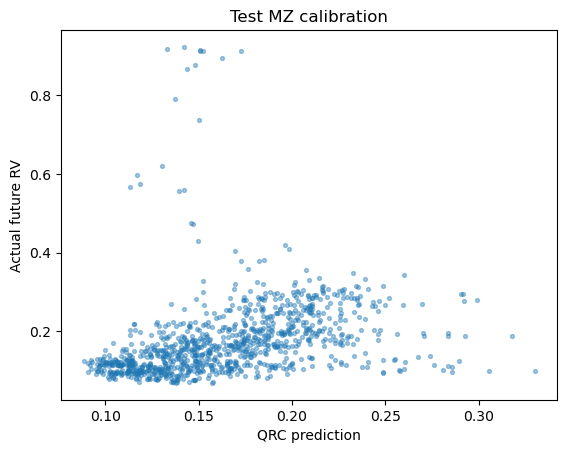

In [9]:
import matplotlib.pyplot as plt

plt.scatter(best_result.test_predictions, y_test, s=8, alpha=0.4)
plt.xlabel("QRC prediction")
plt.ylabel("Actual future RV")
plt.title("Test MZ calibration")
plt.show()